# HeteroSymNN Quickstart

Welcome to HeteroSymNN! This notebook will give you a quick, hands-on introduction to what the framework can do. We will start by building a simple Neural Network to predict a sine wave.

The standout feature of HeteroSymNN compared to traditional frameworks is its native support for **symbolic mathematics** inside activation functions. This allows you to tweak network constants in real-time without having to recompile the computational graph.

First, let's set up the environment and import our tools.

In [ ]:
# In a real Colab, you would uncomment the line below:
# !pip install git+https://github.com/Dilosch03/HeteroSymNN.git

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from HeteroSymNN.Core.Nets import MLP
from HeteroSymNN.API import Wrapper, MinMaxScaler

In [ ]:
# 1. Generating a simple Sine Wave dataset
X = np.linspace(0, 2 * np.pi, 1000).reshape(-1, 1)
y = np.sin(X)

## Creating the Model

Creating a model in HeteroSymNN is designed to be straightforward and highly flexible. Look at the `activation` parameter below: we are passing in a math string (`"relu(x)*alfa"`) alongside a dictionary of initial constants (`{"alfa": 0.1}`).

HeteroSymNN parses this math symbolically, making it incredibly easy to experiment with custom layer behaviors.

In [ ]:
model = MLP(
    nodes_structure=[1, 64, 64, 1], 
    activation=("relu(x)*alfa", {"alfa": 0.1}), 
    output_activation="num", # Linear output
    batch_size=32
)

# The Wrapper automatically handles data normalization and splitting
trainer = Wrapper(model, work_type="reg", input_transformer=MinMaxScaler())
trainer.load_training(X, y)

## Training and Real-Time Tuning

We'll start by training the model for 500 iterations. Once it converges, we'll do something you typically can't do in a standard framework: reach into specific neurons and change their activation math on the fly.

The `change_constants()` method lets you update any symbolic constant — per neuron, per layer — and the change takes effect on the very next forward pass. There's no need to rebuild or recompile anything.

In [11]:
# Initial training
losses = trainer.run_training(num_iterations=500)

# Saving the state and predictions before tuning
train_metrics = trainer.regression_test_accuracy(X, y)
train_predictions = trainer.predict(X)

# The dictionary format is: { layer_index: [(neuron_index, constant_name, new_value), ...] }
# Let's change the 'alfa' constant on the fly!
trainer.model.change_constants({
    1: [(3,"alfa",0.9), (9,"alfa",-15.0)], 
    0: [(3,"alfa",0.6), (18,"alfa",1.0)]
})

# Saving the predictions immediately after tuning (without further training)
tuned_predictions = trainer.predict(X)

## Evaluation and Visualization

Let's evaluate the metrics and plot the results.

By plotting the predictions from *before* and *after* we changed the constants, we can clearly see the immediate impact of real-time symbolic tuning on the network.

R2 Score (Before Tuning): 1.0000
R2 Score (After Tuning): 0.8180


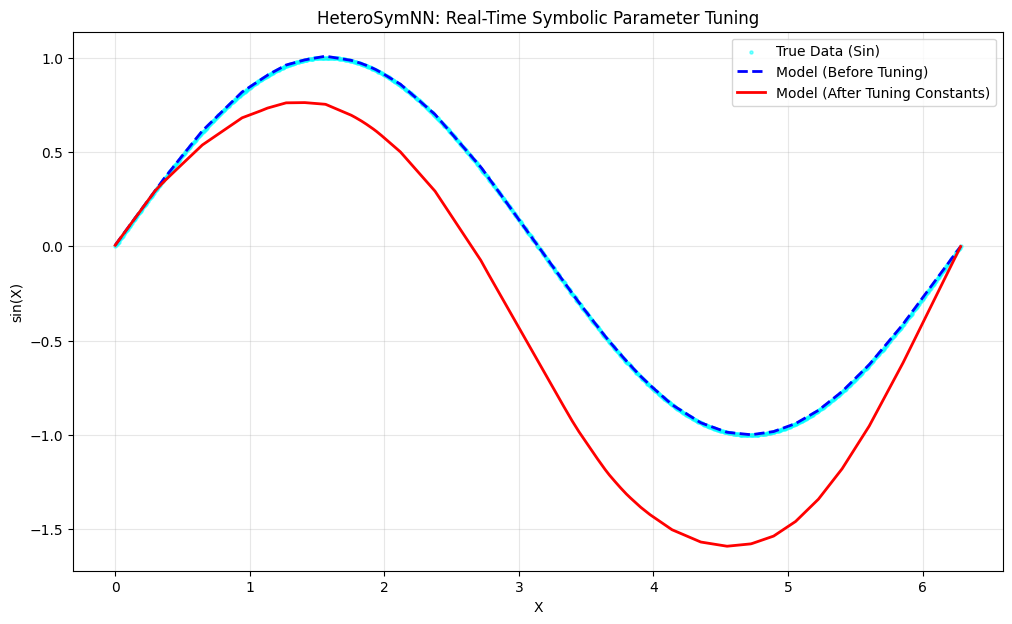

In [13]:
# Print the accuracy from before the tuning
print(f"R2 Score (Before Tuning): {train_metrics['R2']:.4f}")

tuned_metrics = trainer.regression_test_accuracy(X, y)
print(f"R2 Score (After Tuning): {tuned_metrics['R2']:.4f}")

# Plotting the results
plt.figure(figsize=(12, 7))
plt.scatter(X, y, s=5, color='cyan', label='True Data (Sin)', alpha=0.5)

# Plot the model before changing constants
plt.plot(X, train_predictions, color='blue', linestyle='--', label='Model (Before Tuning)', linewidth=2)

# Plot the model immediately after changing constants
plt.plot(X, tuned_predictions, color='red', label='Model (After Tuning Constants)', linewidth=2)

plt.title("HeteroSymNN: Real-Time Symbolic Parameter Tuning")
plt.xlabel("X")
plt.ylabel("sin(X)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()